In [1]:
import os
import sys
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to sys.path
current_path = Path.cwd()
project_root = current_path.parents[1]  # Assuming this file is in VisualScripts/DataAnalysis/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project Root: {project_root}")

# Import project modules
try:
    from RawDataProcessing.ParseLogFile import load_config, parse_logfile
    from RawDataProcessing.GalaxyData import GalDataSet
except ImportError:
    # Fallback if running from a different directory structure
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))
    from RawDataProcessing.ParseLogFile import load_config, parse_logfile
    from RawDataProcessing.GalaxyData import GalDataSet

# Constants for Disk Galaxy Eddington calculation (from ParseLogFile.ll_dg)
G = 112
m_p = 3.365e-65
eta = 0.1
c = 3.07e5
sigma_t = 6.99e-68

def calculate_eddington_limit(mbh):
    """Calculate Eddington accretion rate for a given BH mass."""
    return (4 * np.pi * G * mbh * m_p) / (eta * c * sigma_t)

Project Root: d:\PersonFiles\Codes\Project\MACNet v1


Processing Group Type: elliptical_galaxy
  - Galaxy: elliptical_galaxy_fiducial


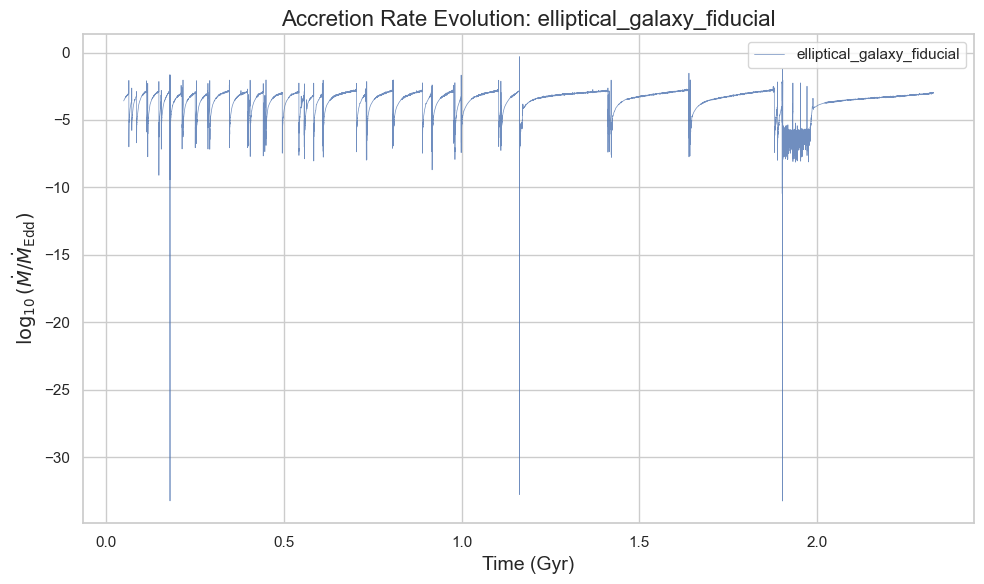

  - Galaxy: elliptical_galaxy_0dot1


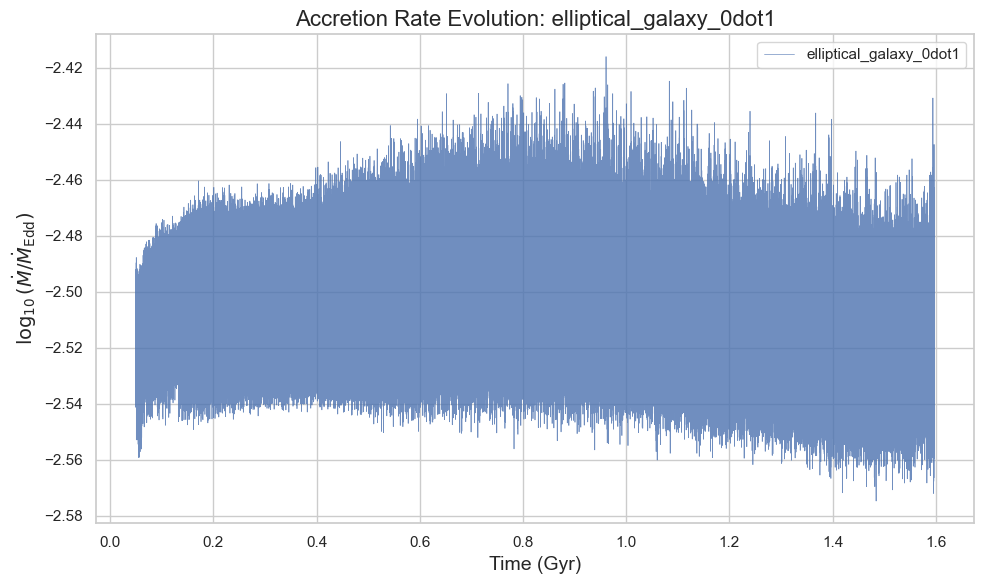

  - Galaxy: elliptical_galaxy_pgc


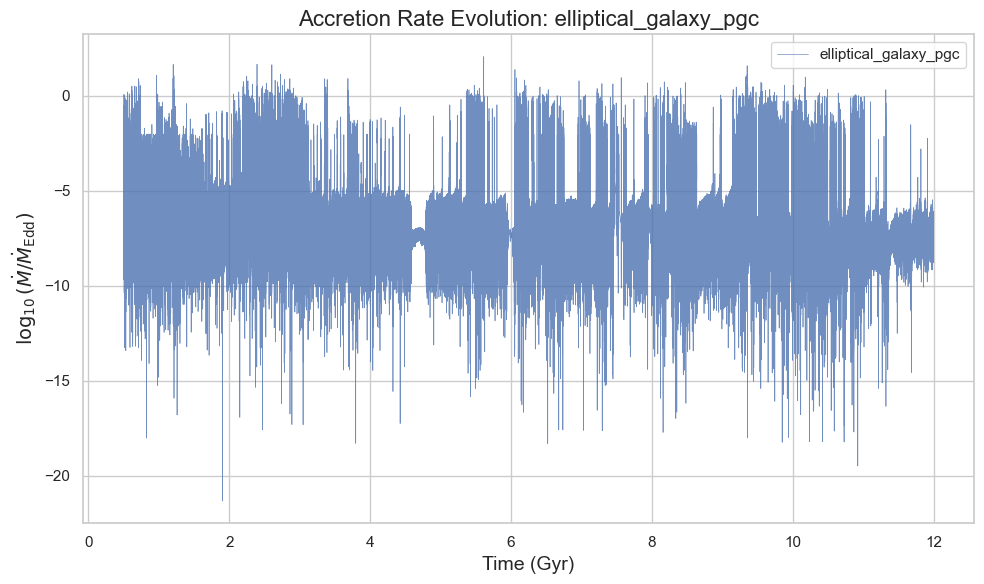

Processing Group Type: disk_galaxy
  - Galaxy: disk_galaxy_fiducial


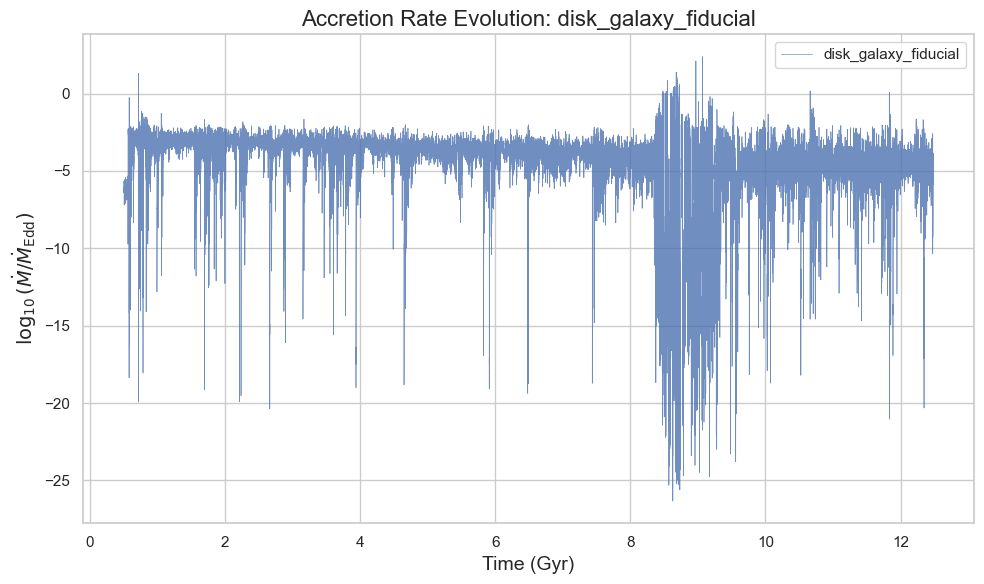

  - Galaxy: disk_galaxy_supplement


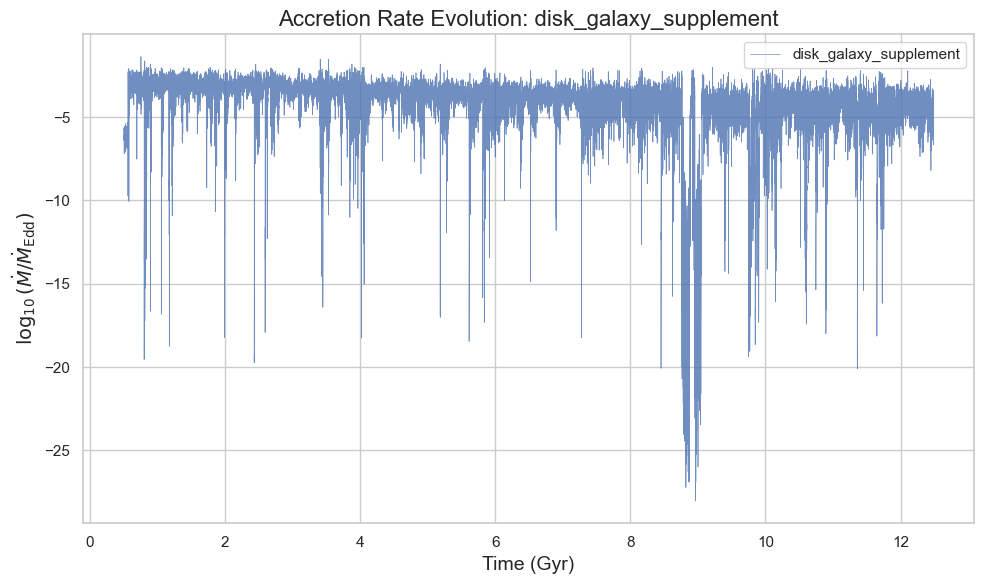

  - Galaxy: disk_galaxy_fiducial_4


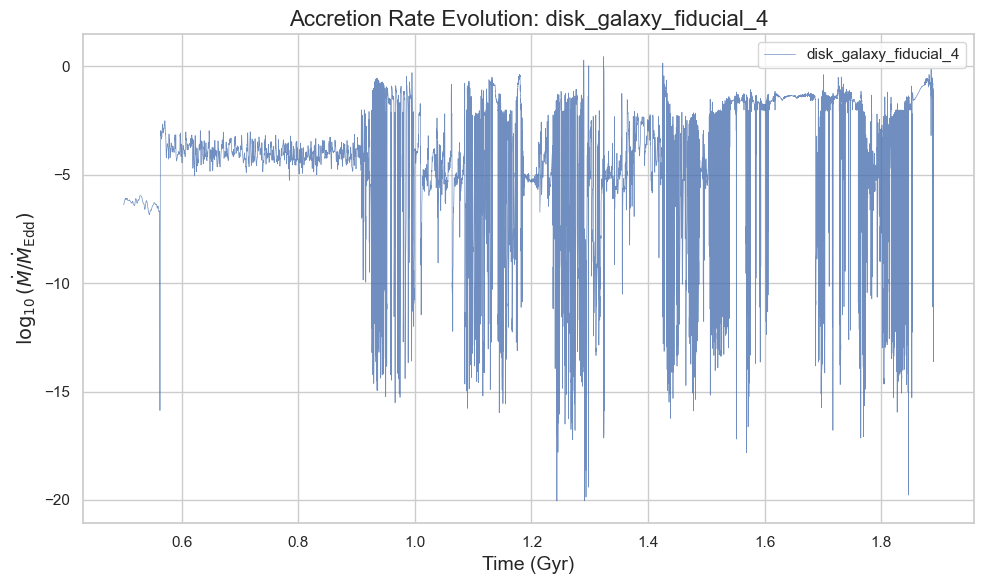

  - Galaxy: disk_galaxy_fiducial_7


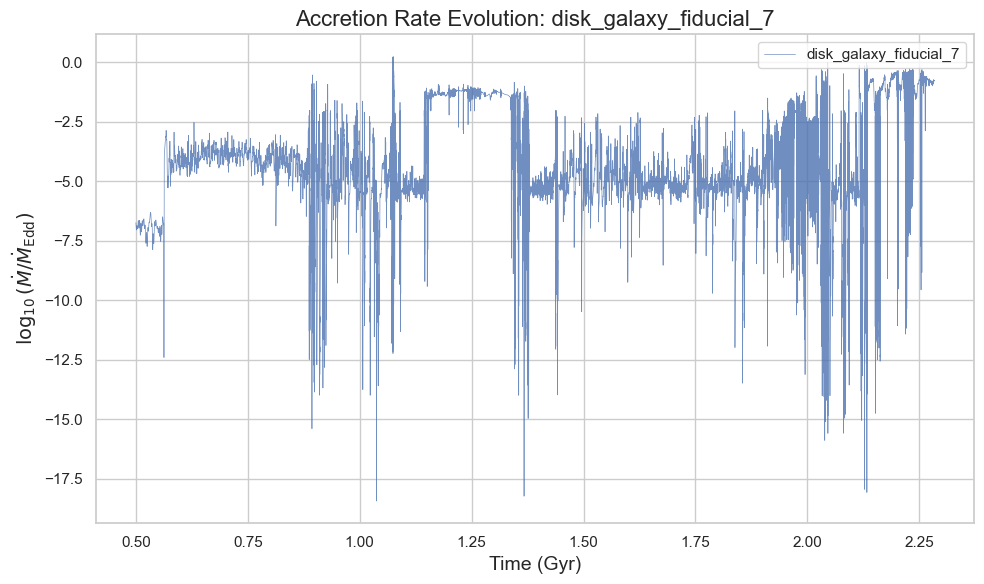

  - Galaxy: disk_galaxy_fiducial_10


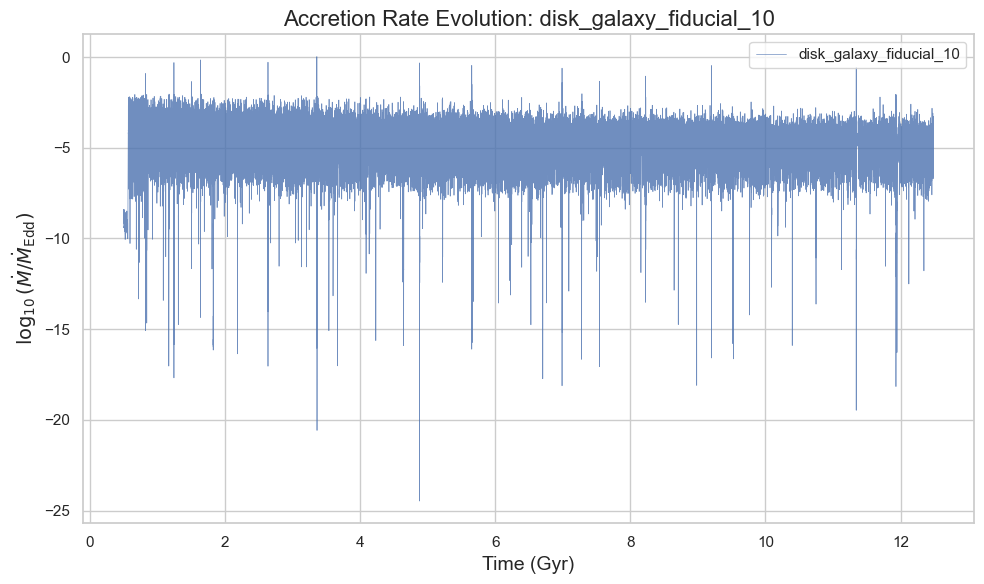

  - Galaxy: disk_galaxy_low


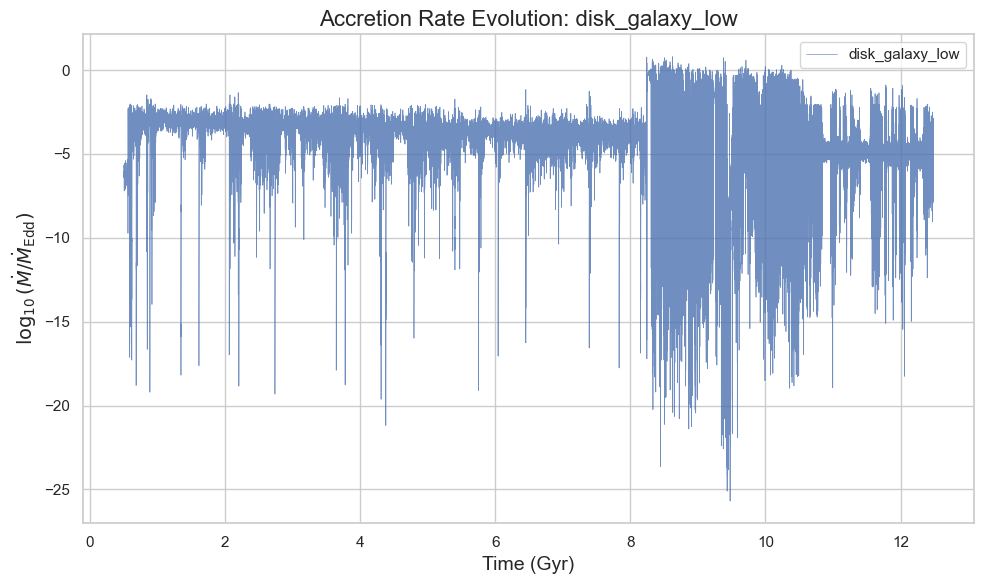

In [2]:
# Load Configurations
configs = load_config(os.path.join(project_root, ".config"))
raw_data_base = configs["BaseConfig"]["raw_data_dir"]
data_dir = configs["BaseConfig"]["data_dir"]
os.makedirs(data_dir, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")

# Iterate over all defined galaxy groups
for gal_type, gal_group in configs["RawDataConfig"].items():
    print(f"Processing Group Type: {gal_type}")
    
    # Get column names for this galaxy type
    if gal_type in configs["HdfraConfig"]:
         col_names = configs["HdfraConfig"][gal_type]["colnames"]
    else:
        print(f"Warning: No column config found for {gal_type}")
        continue
    
    for gal_nickname, gal_config in gal_group.items():
        gal_name = f"{gal_type}_{gal_nickname}"
        print(f"  - Galaxy: {gal_name}")
        
        # Define paths
        raw_log_path = os.path.join(raw_data_base, gal_config["folder_name"], gal_config["log_file"])
        parquet_path = os.path.join(data_dir, f"{gal_name}.parquet")
        
        # Parse/Load Data
        try:
            # This handles loading parquet if exists, or parsing raw log if not
            if not os.path.exists(raw_log_path) and not os.path.exists(parquet_path):
                 print(f"    [Skip] Source log not found: {raw_log_path}")
                 continue

            df = parse_logfile(
                path=raw_log_path, 
                colnames=col_names, 
                save_path=parquet_path, 
                force_parse=False # Set to True to force re-parsing
            )
        except Exception as e:
            print(f"    [Error] Could not load data for {gal_name}: {e}")
            continue
            
        # Process Data for Plotting
        try:
            time = df["time"]
            ratio = None
            
            if "elliptical" in gal_type:
                # For Elliptical: mdot_ratio is strictly mdot / mdot_edd
                # Check directly if column exists
                if "mdot_ratio" in df.columns:
                    ratio = df["mdot_ratio"]
                else:
                    # Fallback if needed
                    ratio = df["mdot"] / df["mdot_edd"]
                    
            elif "disk" in gal_type:
                # For Disk: Calculate Eddington Rate first
                # mdot_bh is the accretion rate
                mbh = df["mbh"]
                mdot_bh = df["mdot_bh"]
                mdot_edd = calculate_eddington_limit(mbh)
                ratio = mdot_bh / mdot_edd
            
            if ratio is not None:
                # Time Truncation Logic
                # Default start time is 0.5 Gyr
                start_time = 0.5
                # Specific start time for selected galaxies
                # Matching user request "elliptical_galaxy_0dot_1" (assuming 0dot1 in config) and "elliptical_galaxy_fiducial"
                if gal_name in ["elliptical_galaxy_0dot1", "elliptical_galaxy_fiducial"]:
                    start_time = 0.05
                
                # Filter out non-positive ratios to avoid log errors AND apply time truncation
                valid_mask = (ratio > 0) & (time >= start_time)
                
                if valid_mask.sum() == 0:
                    print(f"    [Warning] No positive accretion/eddington ratios found or all filtered out by time >= {start_time}.")
                    continue
                
                log_ratio = np.log10(ratio[valid_mask])
                valid_time = time[valid_mask]
                
                # Plot for EACH galaxy
                plt.figure(figsize=(10, 6))
                plt.plot(valid_time, log_ratio, label=gal_name, color='b', alpha=0.8, linewidth=0.5)
                
                plt.xlabel("Time (Gyr)", fontsize=14)
                plt.ylabel(r"$\log_{10}(\dot{M} / \dot{M}_{\rm Edd})$", fontsize=14)
                plt.title(f"Accretion Rate Evolution: {gal_name}", fontsize=16)
                plt.legend(loc='upper right')
                plt.tight_layout()
                plt.show()
                
        except KeyError as e:
            print(f"    [Error] Missing column for calculation: {e}")



Starting H5 Data Analysis (Data/*.h5)

Processing disk_galaxy_fiducial (found 909 .h5 files)...


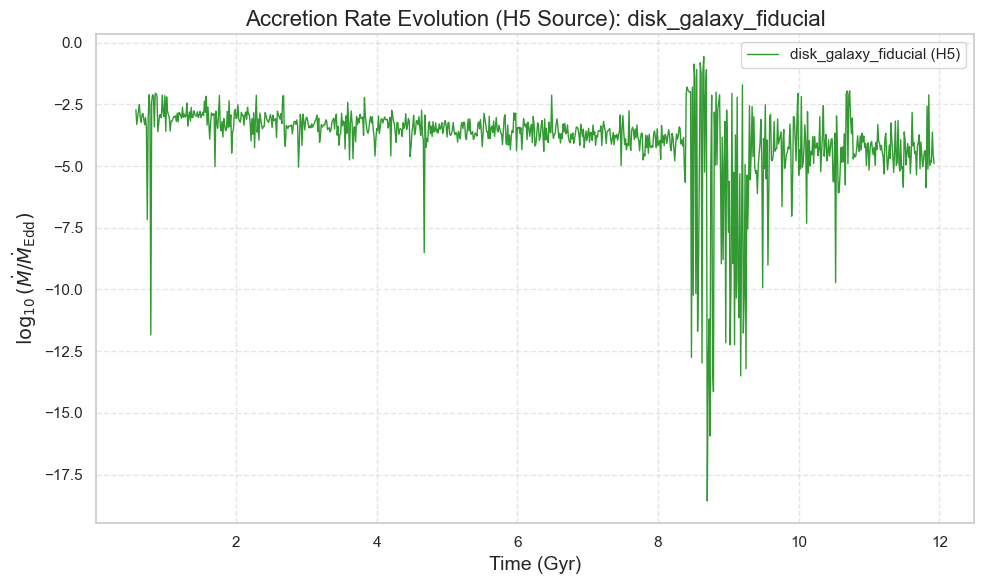

  [Success] Plotted 901 points.
Processing disk_galaxy_fiducial_10 (found 954 .h5 files)...


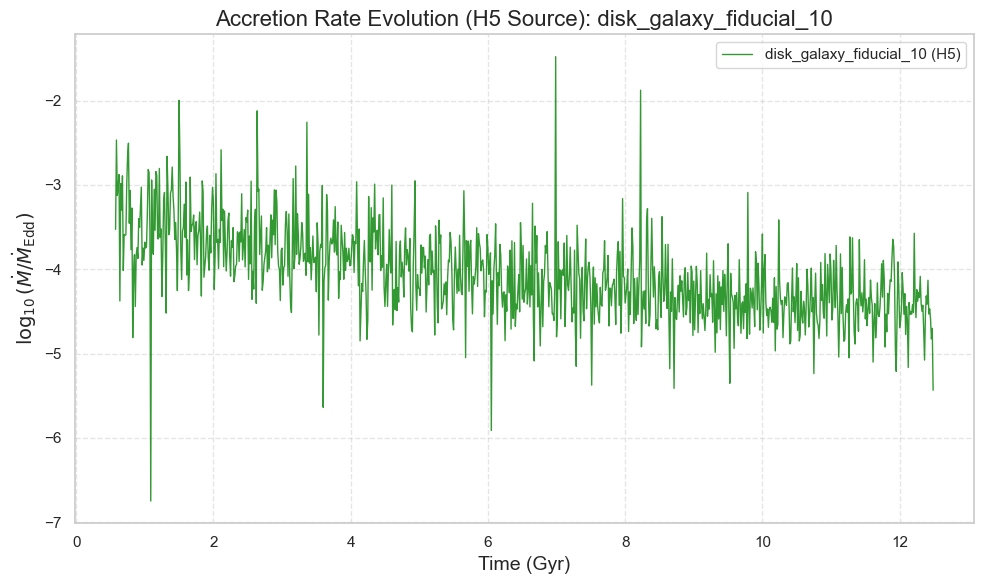

  [Success] Plotted 954 points.
Processing disk_galaxy_fiducial_4 (found 531 .h5 files)...


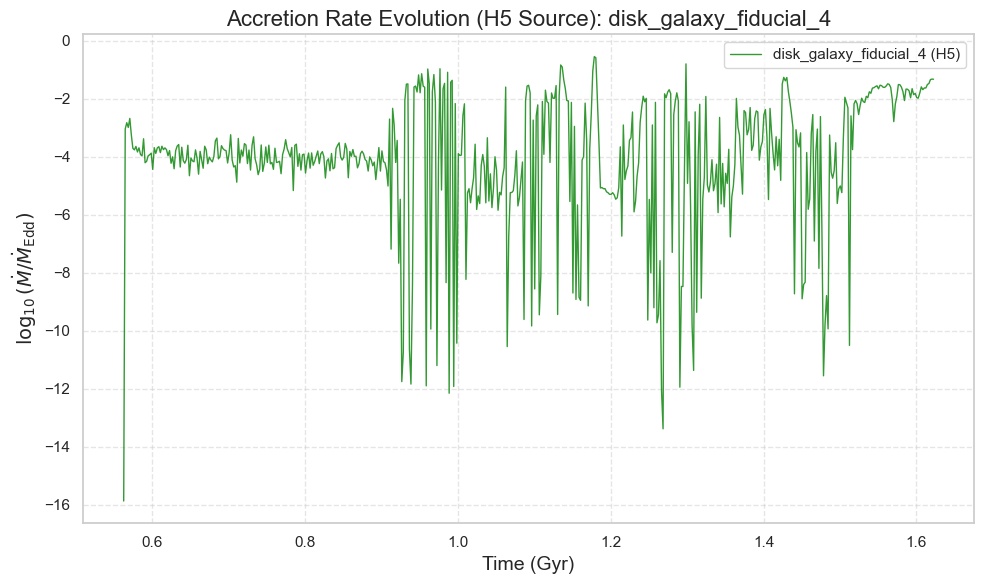

  [Success] Plotted 531 points.
Processing disk_galaxy_fiducial_7 (found 690 .h5 files)...


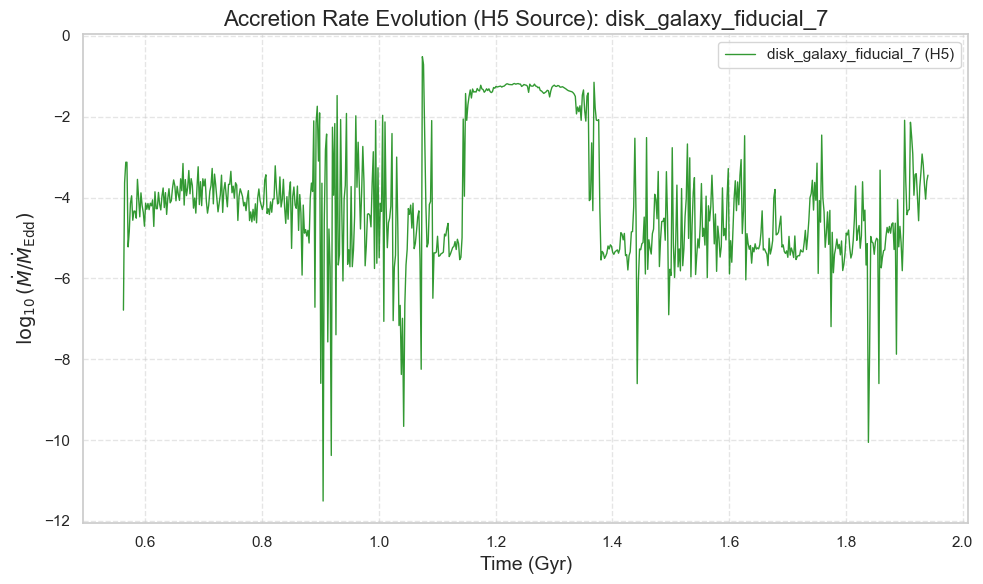

  [Success] Plotted 690 points.
Processing disk_galaxy_low (found 954 .h5 files)...


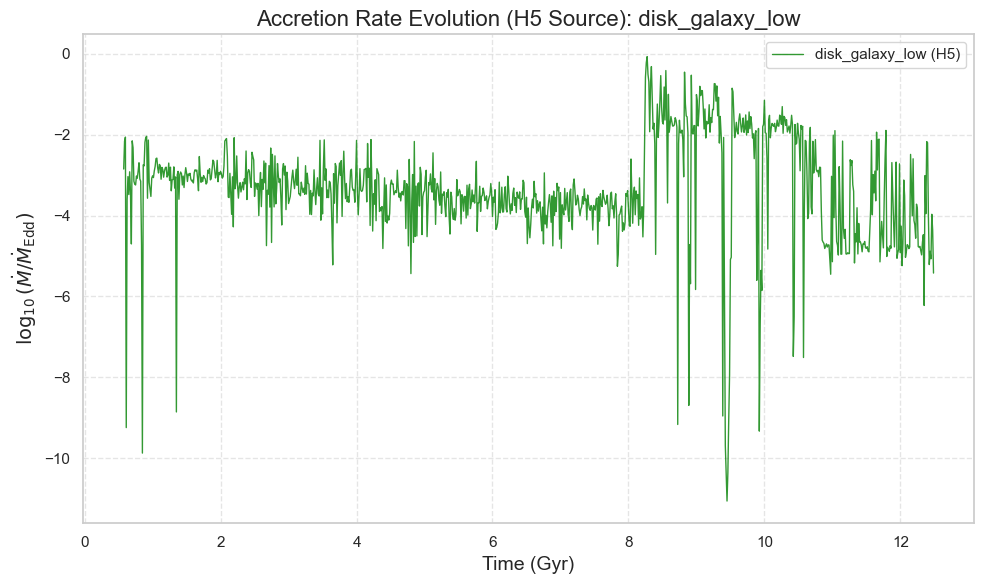

  [Success] Plotted 944 points.
Processing disk_galaxy_supplement (found 1000 .h5 files)...


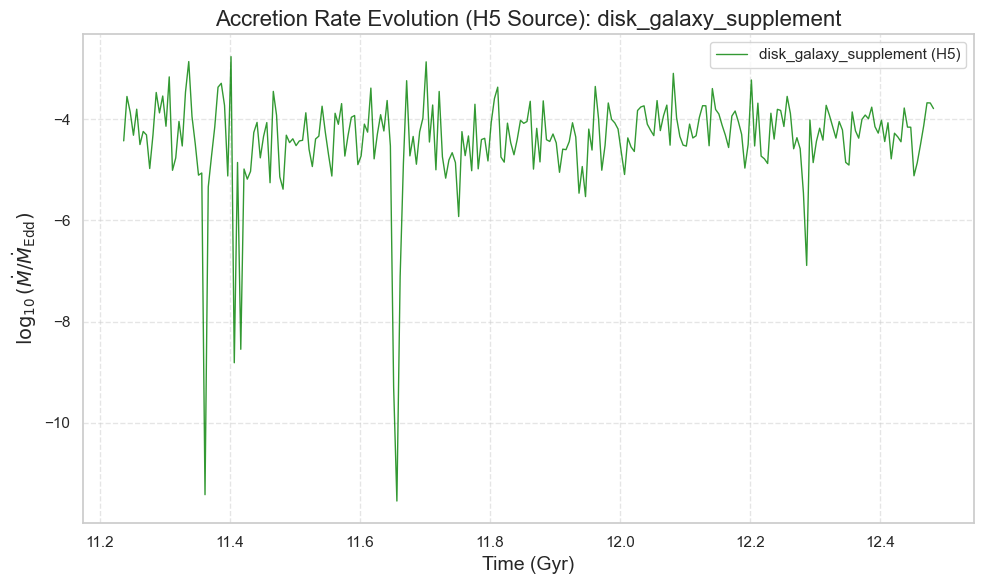

  [Success] Plotted 250 points.
Processing elliptical_galaxy_0dot1 (found 1225 .h5 files)...


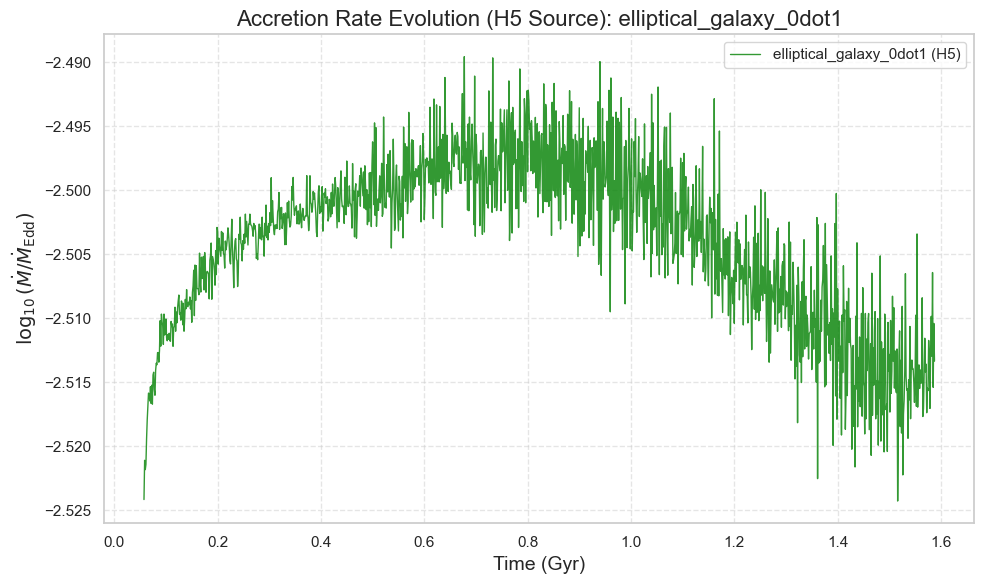

  [Success] Plotted 1225 points.
Processing elliptical_galaxy_fiducial (found 21953 .h5 files)...


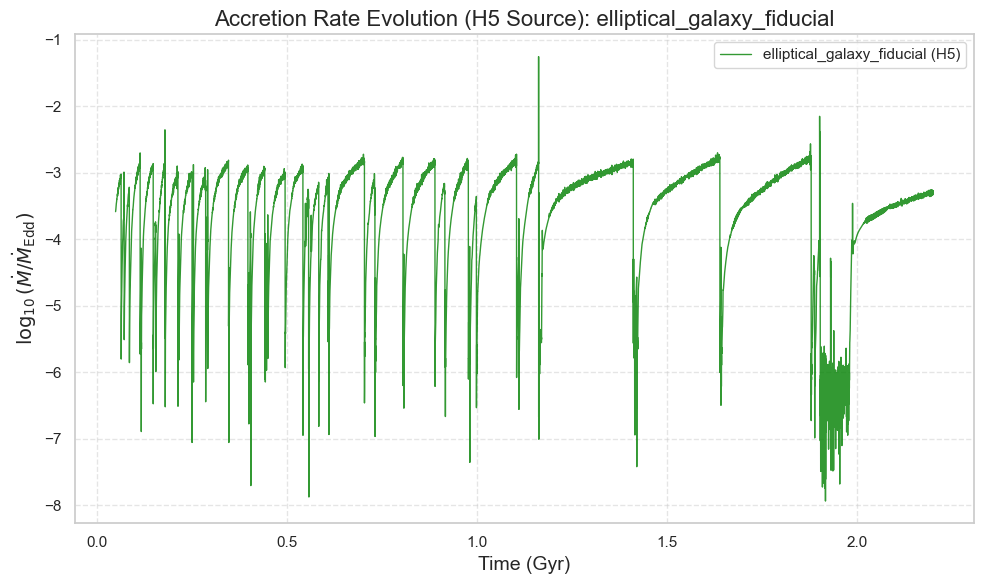

  [Success] Plotted 21488 points.
Processing elliptical_galaxy_pgc (found 915 .h5 files)...


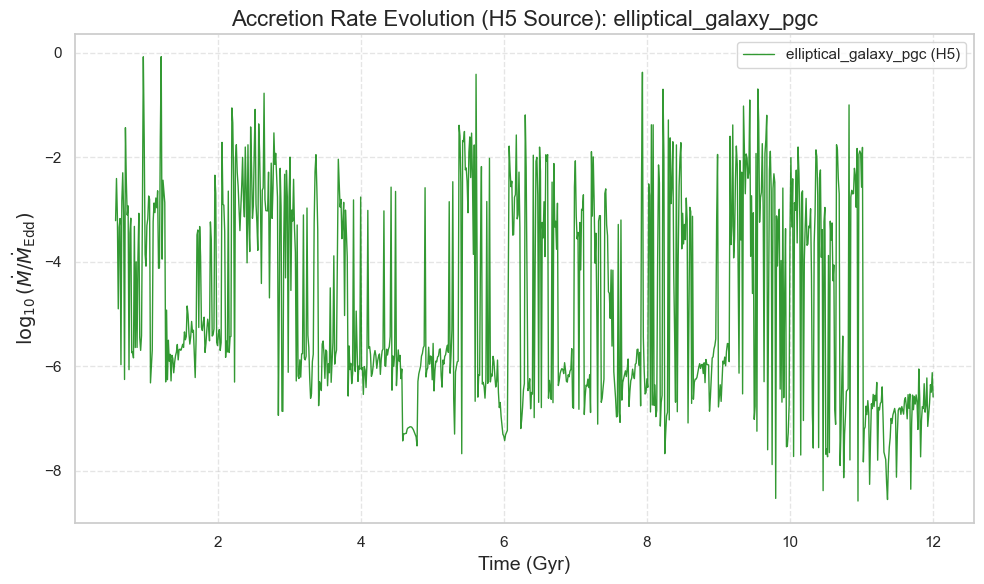

  [Success] Plotted 904 points.


In [3]:
# ==========================================
# Part 2: Analysis from H5 Files (Data Folder)
# ==========================================
# This section reads .h5 files directly from the Data/ directories in the project root
# and plots the accretion rate evolution. This serves as a validation or alternative source 
# relative to the log parsing in Part 1.

print("\n" + "="*50)
print("Starting H5 Data Analysis (Data/*.h5)")
print("="*50 + "\n")

# Define Data Root (Directly accessing the Data folder)
data_root = os.path.join(project_root, "Data")

# Iterate over all directories in Data/ 
# This catches all galaxy folders: e.g., disk_galaxy_fiducial, elliptical_galaxy_0dot1, etc.
target_folders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))])

for gal_name in target_folders:
    # We look for 'coarse' or 'fine' folders. We'll prioritize 'coarse' for general checking.
    coarse_dir = os.path.join(data_root, gal_name, "coarse")
    
    # Check if directory exists
    if not os.path.exists(coarse_dir):
        continue
        
    # Get all .h5 files
    h5_files = sorted(glob.glob(os.path.join(coarse_dir, "*.h5")))
    
    if not h5_files:
        # If no files in coarse, try fine?
        # fine_dir = os.path.join(data_root, gal_name, "fine")
        # h5_files = sorted(glob.glob(os.path.join(fine_dir, "*.h5")))
        # if not h5_files: 
        continue

    print(f"Processing {gal_name} (found {len(h5_files)} .h5 files)...")

    times = []
    ratios = []
    
    # Process each h5 file
    # We use a loop. For very large numbers of files, this might take a moment.
    for h5_file in h5_files:
        try:
            with h5py.File(h5_file, 'r') as f:
                # Ensure log_data group exists
                if 'log_data' not in f:
                    continue
                
                log_data = f['log_data']
                
                # Retrieve Time
                if 'time' in log_data:
                    # [()] reads scalar or full array
                    t = log_data['time'][()]
                else:
                    continue

                # Retrieve Metrics for Ratio
                val_ratio = None
                
                # Logic 1: mdot_bh and mdot_edd (common in disk galaxies)
                if 'mdot_bh' in log_data and 'mdot_edd' in log_data:
                    m_bh = log_data['mdot_bh'][()]
                    m_edd = log_data['mdot_edd'][()]
                    if m_edd != 0:
                        val_ratio = m_bh / m_edd
                
                # Logic 2: mdot and mdot_edd (common in some formats)
                elif 'mdot' in log_data and 'mdot_edd' in log_data:
                     m_dot = log_data['mdot'][()]
                     m_edd = log_data['mdot_edd'][()]
                     if m_edd != 0:
                        val_ratio = m_dot / m_edd
                
                # Logic 3: mdot_ratio direct
                elif 'mdot_ratio' in log_data:
                     val_ratio = log_data['mdot_ratio'][()]

                if val_ratio is not None and val_ratio > 0:
                    times.append(t)
                    ratios.append(val_ratio)

        except Exception as e:
            # Silently skip bad files or print if critical
            # print(f"Error reading {h5_file}: {e}")
            continue
    
    if not times:
        print(f"  [Warning] No valid data extracted for {gal_name}")
        continue
        
    # Convert lists to arrays
    times = np.array(times)
    ratios = np.array(ratios)
    
    # Sort by time (file names usually ordered, but good to be safe)
    sort_idx = np.argsort(times)
    times = times[sort_idx]
    ratios = ratios[sort_idx]
    
    # ----------------------------------------------------------------
    # Plotting
    # ----------------------------------------------------------------
    try:
        # Time Truncation matching Part 1
        start_time = 0.5
        if gal_name in ["elliptical_galaxy_0dot1", "elliptical_galaxy_fiducial"]:
            start_time = 0.05
            
        mask = times >= start_time
        plot_times = times[mask]
        plot_ratios = ratios[mask]

        if len(plot_times) == 0:
             print(f"  [Info] All data points filtered out (time < {start_time}).")
             continue

        log_ratios = np.log10(plot_ratios)
        
        plt.figure(figsize=(10, 6))
        plt.plot(plot_times, log_ratios, label=f"{gal_name} (H5)", color='green', alpha=0.8, linewidth=1)
        
        plt.xlabel("Time (Gyr)", fontsize=14)
        plt.ylabel(r"$\log_{10}(\dot{M} / \dot{M}_{\rm Edd})$", fontsize=14)
        plt.title(f"Accretion Rate Evolution (H5 Source): {gal_name}", fontsize=16)
        plt.legend(loc='upper right')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
        print(f"  [Success] Plotted {len(plot_times)} points.")
        
    except Exception as e:
        print(f"  [Error] Plotting failed for {gal_name}: {e}")


Starting Time Step (dt) Evolution Analysis (.parquet)

Processing Group Type: elliptical_galaxy
  - Galaxy: elliptical_galaxy_fiducial


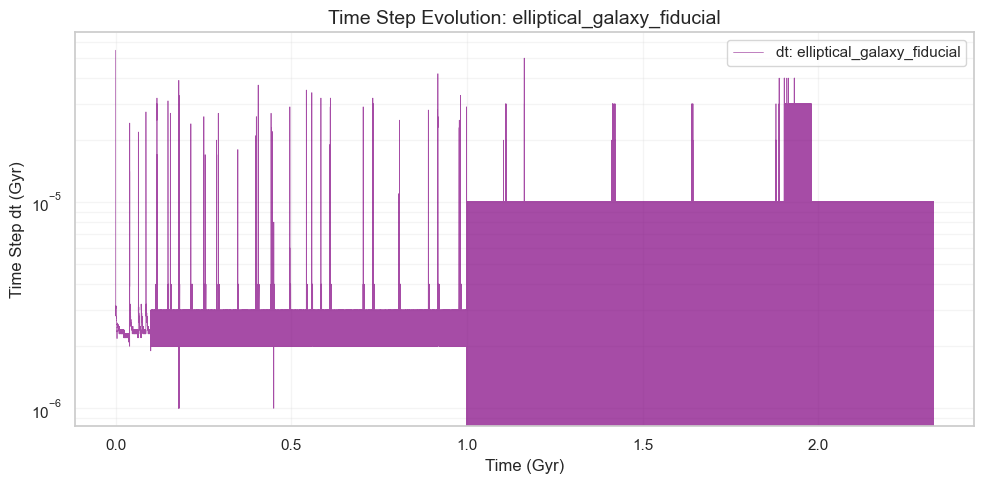

  - Galaxy: elliptical_galaxy_0dot1


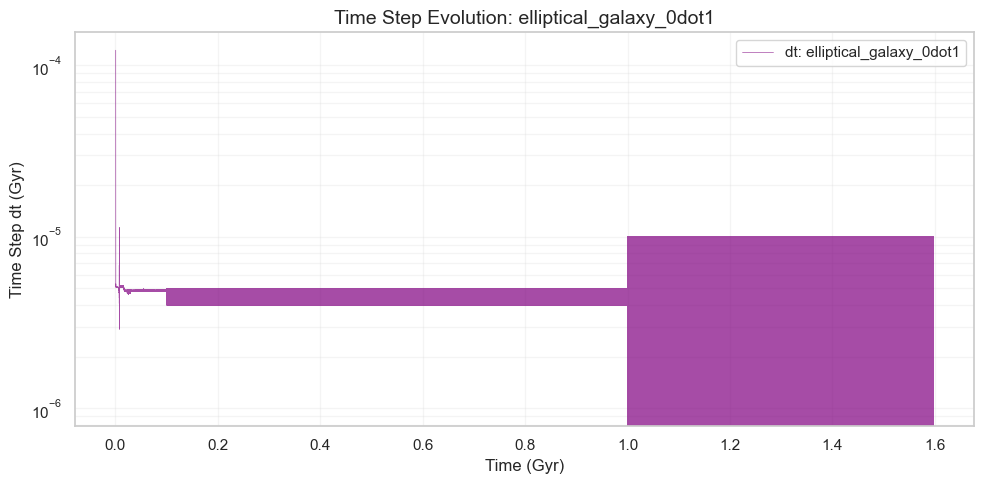

  - Galaxy: elliptical_galaxy_pgc


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 1000x500 with 1 Axes>

Processing Group Type: disk_galaxy
  - Galaxy: disk_galaxy_fiducial


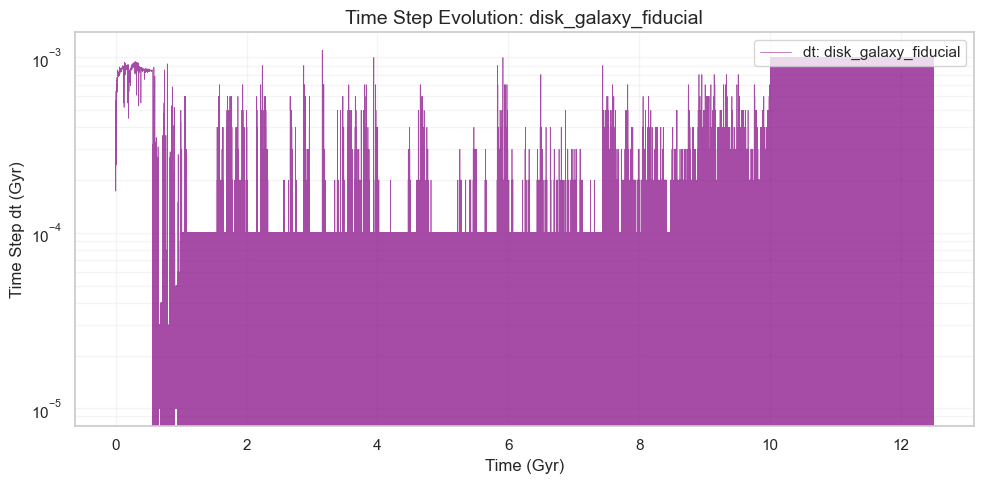

  - Galaxy: disk_galaxy_supplement


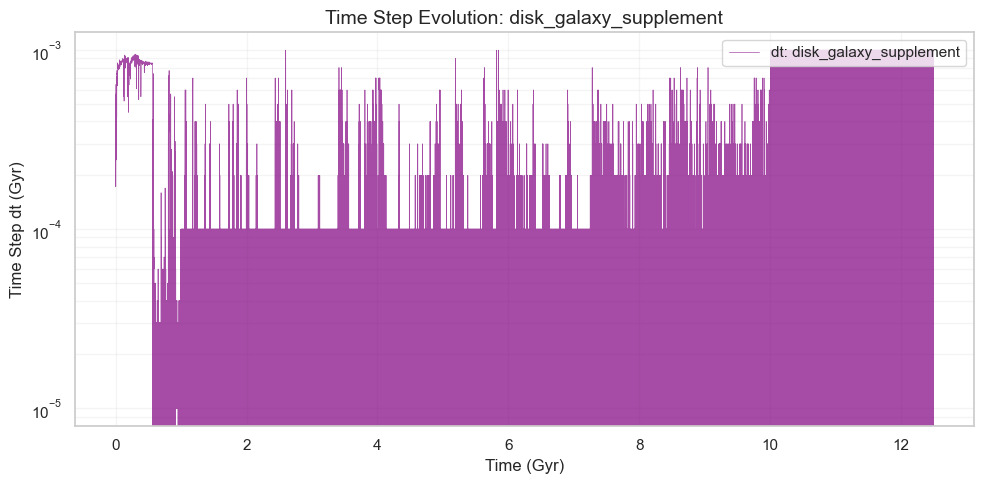

  - Galaxy: disk_galaxy_fiducial_4


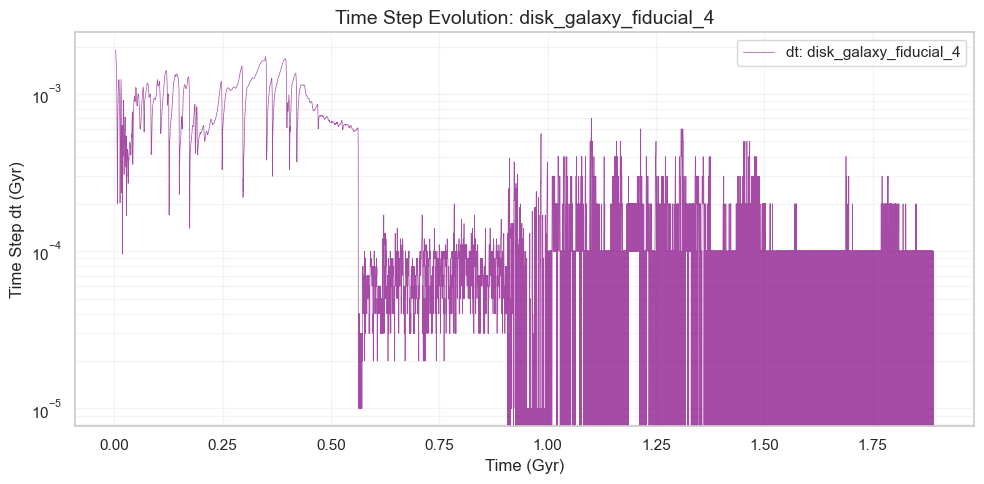

  - Galaxy: disk_galaxy_fiducial_7


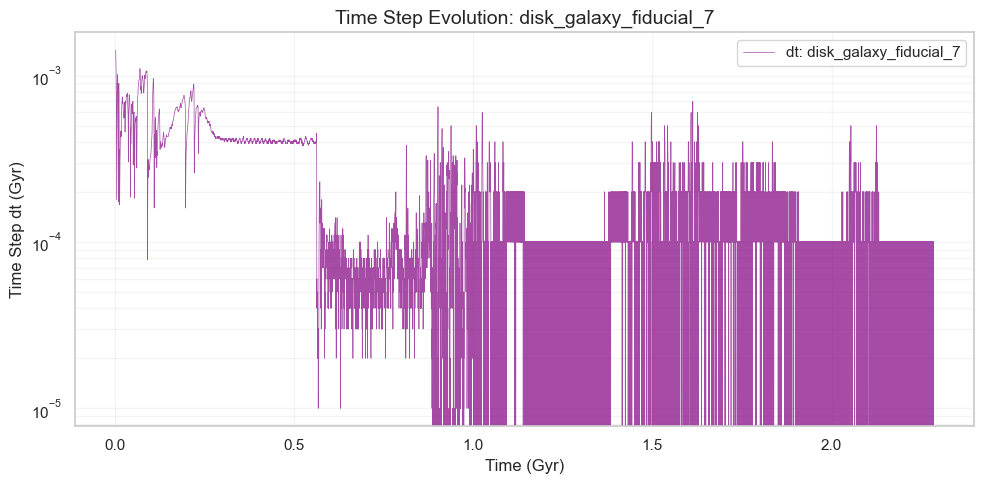

  - Galaxy: disk_galaxy_fiducial_10


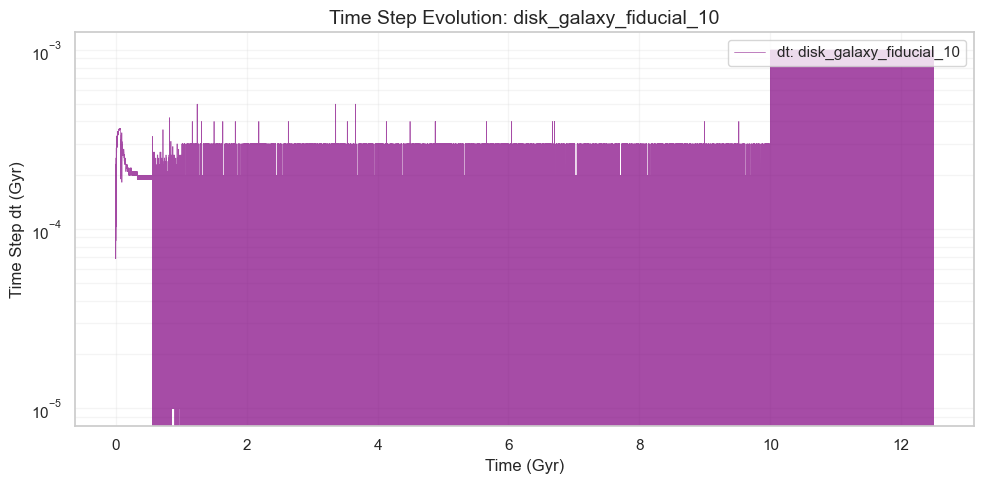

  - Galaxy: disk_galaxy_low


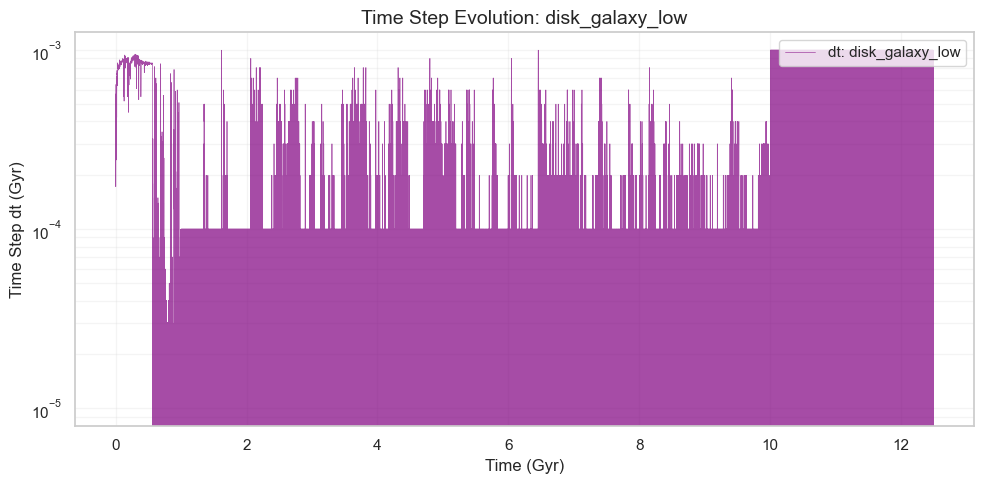

In [4]:
# ==========================================
# Part 3: Time Step (dt) Evolution Analysis
# ==========================================
# This section plots the evolution of the simulation time step (dt) over time.
# Useful for checking numerical stability or adaptive time-stepping behavior.

print("\n" + "="*50)
print("Starting Time Step (dt) Evolution Analysis (.parquet)")
print("="*50 + "\n")

# Iterate over all defined galaxy groups
for gal_type, gal_group in configs["RawDataConfig"].items():
    print(f"Processing Group Type: {gal_type}")
    
    for gal_nickname, gal_config in gal_group.items():
        gal_name = f"{gal_type}_{gal_nickname}"
        print(f"  - Galaxy: {gal_name}")
        
        # Define path to parquet (generated in Part 1)
        parquet_path = os.path.join(data_dir, f"{gal_name}.parquet")
        
        if not os.path.exists(parquet_path):
            print(f"    [Skip] Parquet file not found: {parquet_path}")
            continue
            
        try:
            # Load Data
            df = pd.read_parquet(parquet_path)
            
            # Check columns
            if "time" not in df.columns:
                print(f"    [Warning] Missing 'dt' or 'time' column in {gal_name}")
                continue
                
            time = df["time"]
            
            # Clean Data (ensure positive time)
            mask = time > 0
            valid_time = time[mask]
            
            if len(valid_time) == 0:
                print("    [Warning] No valid data points.")
                continue

            # Plot
            plt.figure(figsize=(10, 5))
            # dt often spans orders of magnitude, so log scale is usually preferred for Y
            plt.semilogy(valid_time, valid_time.diff(), label=f"dt: {gal_name}", color='purple', alpha=0.7, linewidth=0.5)
            
            plt.xlabel("Time (Gyr)", fontsize=12)
            plt.ylabel("Time Step dt (Gyr)", fontsize=12)
            plt.title(f"Time Step Evolution: {gal_name}", fontsize=14)
            plt.legend(loc="upper right")
            plt.grid(True, which="both", ls="-", alpha=0.2)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"    [Error] Failed to analyze dt for {gal_name}: {e}")


In [5]:
# ==========================================
# Part 4: Check time spacing for Disk Galaxy fiducial_4 and fiducial_7 (.parquet)
# ==========================================

import os
import numpy as np
import pandas as pd
from pathlib import Path

# Ensure data_dir and configs are available; if not, load them
try:
    data_dir
except NameError:
    try:
        from RawDataProcessing.ParseLogFile import load_config
        project_root = Path.cwd().parents[1]
        configs = load_config(os.path.join(project_root, ".config"))
        data_dir = configs["BaseConfig"]["data_dir"]
    except Exception as e:
        raise RuntimeError(f"Failed to determine data_dir: {e}")

# Target galaxy parquet files
gal_names = ["disk_galaxy_fiducial_4", "disk_galaxy_fiducial_7"]
parquet_paths = {name: os.path.join(data_dir, f"{name}.parquet") for name in gal_names}

# Store results for reuse
results = {}

def summarize_time_spacing_from_df(df: pd.DataFrame, label: str):
    if "time" not in df.columns:
        print(f"[{label}] Missing 'time' column.")
        return None
    time = df["time"].to_numpy()
    dt = np.diff(time)
    if dt.size == 0:
        print(f"[{label}] Not enough time points to compute intervals.")
        return None

    # Round to avoid tiny floating errors when listing uniques
    unique_vals, counts = np.unique(np.round(dt, 12), return_counts=True)

    print(f"[{label}] points={len(time)}, intervals={len(dt)}")
    print(f"  dt stats: min={dt.min():.6g}, max={dt.max():.6g}, mean={dt.mean():.6g}, median={np.median(dt):.6g}")
    print("  unique dt values (rounded):")
    for u, c in zip(unique_vals, counts):
        print(f"    {u:.6g} (n={c})")

    # Optional: compare with expected dt from configs if available
    try:
        expected_dt = None
        if isinstance(configs, dict) and "RawDataConfig" in configs and "disk_galaxy" in configs["RawDataConfig"]:
            nickname = label.split("disk_galaxy_")[-1]
            cfg_group = configs["RawDataConfig"]["disk_galaxy"]
            if nickname in cfg_group:
                gal_cfg = cfg_group[nickname]
                expected_dt = gal_cfg.get("snapshot_dt", gal_cfg.get("dt", None))
        if expected_dt is not None:
            print(f"  expected dt (from config): {expected_dt}")
    except Exception:
        pass

    return {"time": time, "dt": dt}

# Read and summarize each parquet
for name, path in parquet_paths.items():
    if not os.path.exists(path):
        print(f"[{name}] Parquet not found: {path}")
        continue
    try:
        df = pd.read_parquet(path)
    except Exception as e:
        print(f"[{name}] Failed to read parquet: {e}")
        continue
    res = summarize_time_spacing_from_df(df, name)
    if res is not None:
        results[name] = res

# Define convenient variables for reuse in later analysis
dt_fiducial4 = results.get("disk_galaxy_fiducial_4", {}).get("dt", np.array([]))
dt_fiducial7 = results.get("disk_galaxy_fiducial_7", {}).get("dt", np.array([]))

print("\nSummary variables:")
print(f"  dt_fiducial4 length: {dt_fiducial4.size}")
print(f"  dt_fiducial7 length: {dt_fiducial7.size}")


[disk_galaxy_fiducial_4] points=497950, intervals=497949
  dt stats: min=0, max=0.0019004, mean=3.79517e-06, median=0
  unique dt values (rounded):
    0 (n=478742)
    1e-05 (n=4385)
    2e-05 (n=553)
    3e-05 (n=604)
    4e-05 (n=890)
    5e-05 (n=962)
    6e-05 (n=851)
    7e-05 (n=739)
    8e-05 (n=557)
    9e-05 (n=498)
    9.6e-05 (n=1)
    0.0001 (n=7253)
    0.000106 (n=1)
    0.00011 (n=134)
    0.00012 (n=64)
    0.00013 (n=36)
    0.00014 (n=27)
    0.00015 (n=22)
    0.00016 (n=12)
    0.000168 (n=1)
    0.00017 (n=9)
    0.00018 (n=5)
    0.00019 (n=8)
    0.0002 (n=622)
    0.0002004 (n=1)
    0.000201 (n=1)
    0.000203 (n=1)
    0.00021 (n=2)
    0.00022 (n=6)
    0.00023 (n=5)
    0.000236 (n=1)
    0.00024 (n=4)
    0.00025 (n=5)
    0.000257 (n=1)
    0.00026 (n=1)
    0.000265 (n=1)
    0.00027 (n=5)
    0.000273 (n=1)
    0.000278 (n=1)
    0.00028 (n=3)
    0.00029 (n=2)
    0.000299 (n=1)
    0.0003 (n=170)
    0.000308 (n=2)
    0.00031 (n=6)
    0.000316 (n=1)